**Task-1-** *Data Set*

**Task-1-** *Data Set*

In [8]:
import pandas as pd

df = pd.read_csv("mckinsey (1).csv")

print(df.head())
print(df.dtypes)
print(df.shape)

       country  year  population continent  life_exp     gdp_cap
0  Afghanistan  1952     8425333      Asia    28.801  779.445314
1  Afghanistan  1957     9240934      Asia    30.332  820.853030
2  Afghanistan  1962    10267083      Asia    31.997  853.100710
3  Afghanistan  1967    11537966      Asia    34.020  836.197138
4  Afghanistan  1972    13079460      Asia    36.088  739.981106
country        object
year            int64
population      int64
continent      object
life_exp      float64
gdp_cap       float64
dtype: object
(1704, 6)


**Task-2-**Null Values

In [9]:
null_count = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100

print("Null Count:")
print(null_count)

print("\nNull Percentage:")
print(null_percentage)

Null Count:
country       0
year          0
population    0
continent     0
life_exp      0
gdp_cap       0
dtype: int64

Null Percentage:
country       0.0
year          0.0
population    0.0
continent     0.0
life_exp      0.0
gdp_cap       0.0
dtype: float64


Task-3-Duplicate Detection and Removal

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Duplicate Rows: 0
Shape after removing duplicates:
(1704, 6)


**Task-4-** *Data Type Correction*

In [13]:
# Memory usage before conversion
print("Memory Usage Before:")
print(df.memory_usage(deep=True).sum())

# Convert repetitive string column to category
df["continent"] = df["continent"].astype("category")

# Memory usage after conversion
print("\nMemory Usage After:")
print(df.memory_usage(deep=True).sum())

# Check data types
print("\nUpdated Data Types:")
print(df.dtypes)

Memory Usage Before:
245940

Memory Usage After:
154540

Updated Data Types:
country         object
year             int64
population       int64
continent     category
life_exp       float64
gdp_cap        float64
dtype: object


**Task-5-** *Descriptive Statics and Skewness*

In [14]:
# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe())

# Skewness of numeric columns
skewness = df.select_dtypes(include=['int64','float64']).skew()

print("\nSkewness:")
print(skewness)

# Column with highest absolute skewness
highest_skew = skewness.abs().idxmax()

print("\nColumn with Highest Absolute Skewness:", highest_skew)
print("Skewness Value:", skewness[highest_skew])

Descriptive Statistics:
             year    population     life_exp        gdp_cap
count  1704.00000  1.704000e+03  1704.000000    1704.000000
mean   1979.50000  2.960121e+07    59.474439    7215.327081
std      17.26533  1.061579e+08    12.917107    9857.454543
min    1952.00000  6.001100e+04    23.599000     241.165876
25%    1965.75000  2.793664e+06    48.198000    1202.060309
50%    1979.50000  7.023596e+06    60.712500    3531.846988
75%    1993.25000  1.958522e+07    70.845500    9325.462346
max    2007.00000  1.318683e+09    82.603000  113523.132900

Skewness:
year          0.000000
population    8.340218
life_exp     -0.252702
gdp_cap       3.850272
dtype: float64

Column with Highest Absolute Skewness: population
Skewness Value: 8.340217715355305


**Task-6-** *Outlier Detetction with IQR*

In [15]:
numeric_columns = ["life_exp", "gdp_cap"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))



Column: life_exp
Q1: 48.198
Q3: 70.8455
IQR: 22.6475
Lower Bound: 14.226750000000003
Upper Bound: 104.81675
Number of Outliers: 0

Column: gdp_cap
Q1: 1202.06030925
Q3: 9325.462346
IQR: 8123.40203675
Lower Bound: -10983.042745875
Upper Bound: 21510.565401125
Number of Outliers: 143


**Task-5-** *Visualization*

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

**Line Plot**

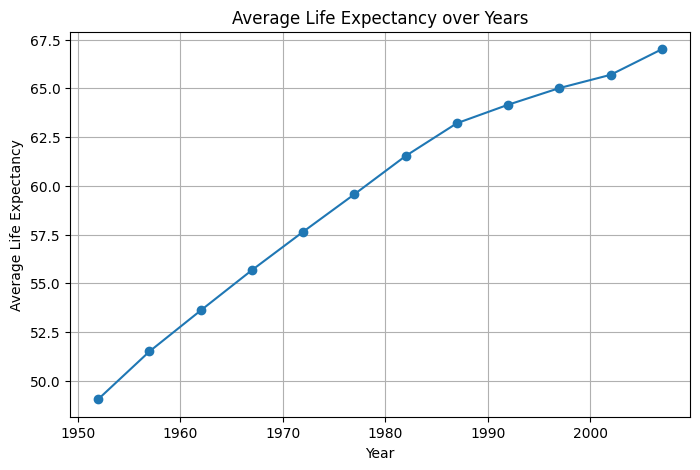

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [17]:
plt.figure(figsize=(8,5))

yearly = df.groupby("year")["life_exp"].mean()

plt.plot(yearly.index, yearly.values, marker="o")

plt.title("Average Life Expectancy over Years")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.grid(True)

plt.show()
plt.figure(figsize=(8,5))


**Bar Chart**

/tmp/ipykernel_596/2350341113.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("continent")["life_exp"].mean().plot(kind="bar")


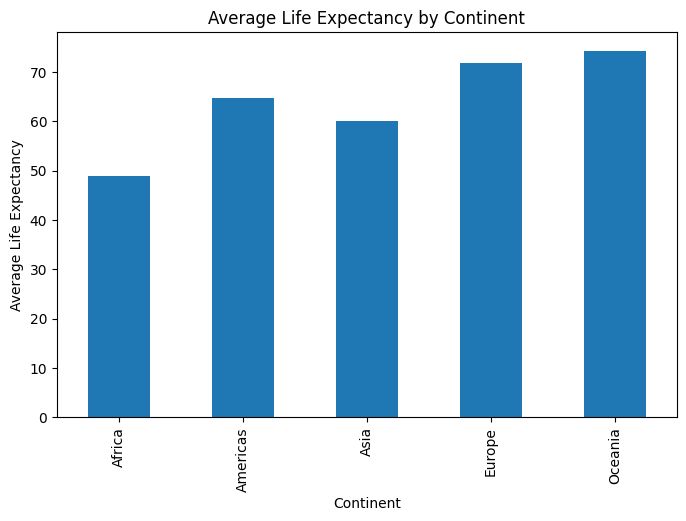

In [18]:
plt.figure(figsize=(8,5))

df.groupby("continent")["life_exp"].mean().plot(kind="bar")

plt.title("Average Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")

plt.show()

**Histogram**

/tmp/ipykernel_596/2350341113.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("continent")["life_exp"].mean().plot(kind="bar")


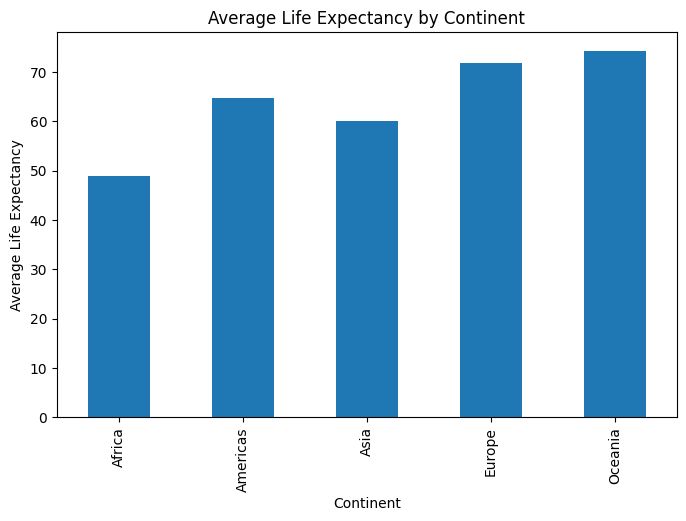

In [19]:
plt.figure(figsize=(8,5))

df.groupby("continent")["life_exp"].mean().plot(kind="bar")

plt.title("Average Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")

plt.show()

**Scratter Plot**

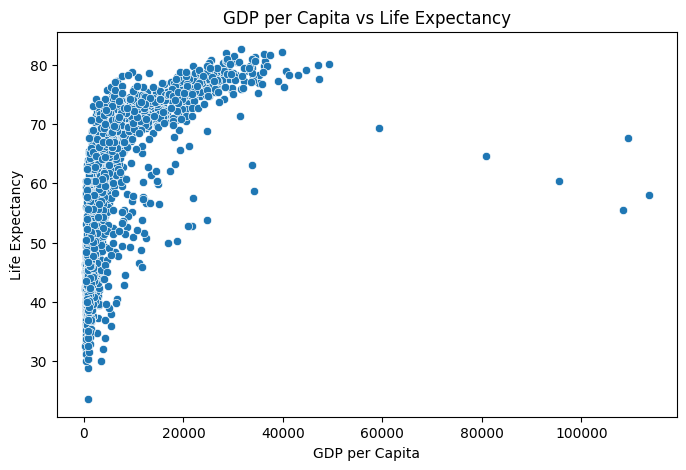

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="gdp_cap", y="life_exp", data=df)
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.show()

In [ ]:
README: The scatter plot shows a positive correlation between GDP per Capita and
 Life Expectancy. As GDP per Capita increases, Life Expectancy also tends to increase.
  The relationship is moderately positive because the points are scattered and
  not perfectly aligned. Other factors such as healthcare, education, and living conditions may also influence life expectancy.

**Box Plot**

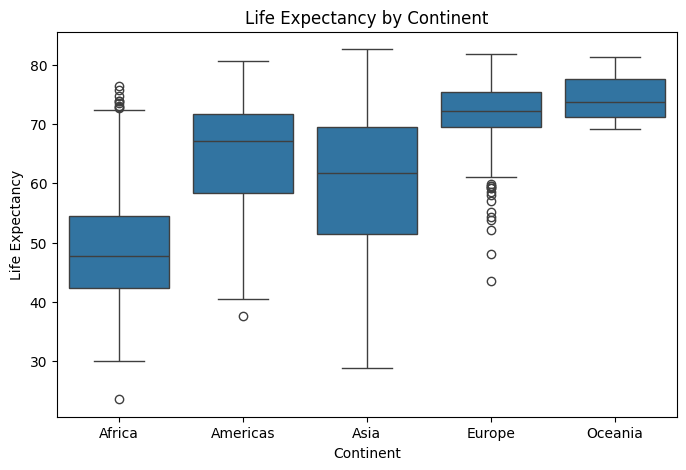

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="continent", y="life_exp", data=df)
plt.title("Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Life Expectancy")
plt.show()

**Task-8-** *Correlation Heatmap*

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

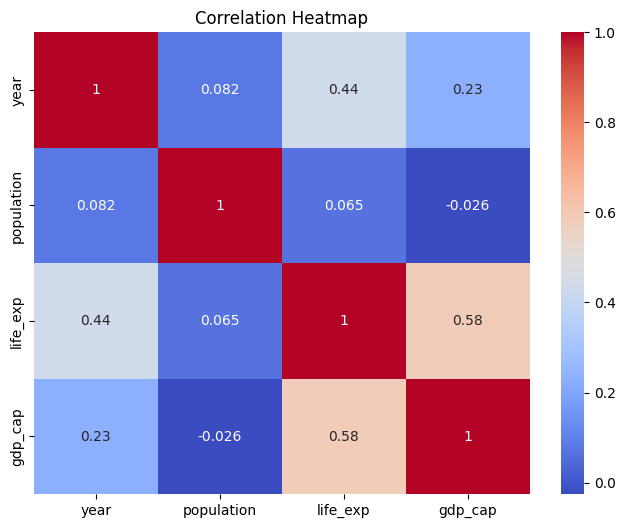

Highest Correlation Pair: ('life_exp', 'gdp_cap')
Correlation Value: 0.5837062198659794


In [23]:
# Sirf numeric columns ka correlation
corr = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Highest correlation pair
corr_unstack = corr.abs().unstack()
corr_unstack = corr_unstack[corr_unstack < 1]   # self-correlation hata diya
highest = corr_unstack.idxmax()

print("Highest Correlation Pair:", highest)
print("Correlation Value:", corr.loc[highest[0], highest[1]])

In [ ]:
### Interpretation

A correlation heatmap was created to examine the relationships among numerical variables.
 The pair with the highest correlation was identified from the correlation matrix.

A high correlation indicates a strong association between two variables, but it
 does not imply causation. Other factors such as healthcare, education, or economic
  development may also influence the observed relationship.

**Task-9**

 *Imputation Strategy Comparison*

In [24]:
# Numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Skewness
skewness = df[numeric_cols].skew().abs().sort_values(ascending=False)

# Top 2 most skewed columns
top2 = skewness.index[:2]

for col in top2:
    print(f"\nColumn: {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())

    # Fill missing values with median
    df[col].fillna(df[col].median(), inplace=True)

# Check remaining null values
print("\nRemaining Null Values:")
print(df[top2].isnull().sum())


Column: population
Mean: 29601212.324530516
Median: 7023595.5

Column: gdp_cap
Mean: 7215.327081212149
Median: 3531.8469885

Remaining Null Values:
population    0
gdp_cap       0
dtype: int64


/tmp/ipykernel_596/4267657789.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


*Spearman Rank Correlation*

In [25]:
# Pearson Correlation
pearson = df.corr(numeric_only=True)

# Spearman Correlation
spearman = df.corr(method='spearman', numeric_only=True)

print("Pearson Correlation")
print(pearson)

print("\nSpearman Correlation")
print(spearman)

# Difference
difference = spearman - pearson

print("\nDifference (Spearman - Pearson)")
print(difference)

Pearson Correlation
                year  population  life_exp   gdp_cap
year        1.000000    0.082308  0.435611  0.227318
population  0.082308    1.000000  0.064955 -0.025600
life_exp    0.435611    0.064955  1.000000  0.583706
gdp_cap     0.227318   -0.025600  0.583706  1.000000

Spearman Correlation
                year  population  life_exp   gdp_cap
year        1.000000    0.219808  0.445865  0.226905
population  0.219808    1.000000  0.180612  0.052252
life_exp    0.445865    0.180612  1.000000  0.826471
gdp_cap     0.226905    0.052252  0.826471  1.000000

Difference (Spearman - Pearson)
                year  population  life_exp   gdp_cap
year        0.000000    0.137500  0.010254 -0.000413
population  0.137500    0.000000  0.115657  0.077851
life_exp    0.010254    0.115657  0.000000  0.242765
gdp_cap    -0.000413    0.077851  0.242765  0.000000


In [ ]:
## Task 9: Imputation Strategy and Spearman Correlation


### Interpretation

The mean and median values were compared for the most skewed numeric columns.
 Since skewed data is affected by extreme values, median imputation was considered
 more appropriate than mean imputation.

Pearson and Spearman correlation methods were compared. Pearson measures linear
 relationships, whereas Spearman measures monotonic relationships based on ranks.
 Spearman correlation is generally more robust in the presence of outliers or non-linear relationships.

**Grouped Aggregation**

In [26]:
group_stats = df.groupby("continent")["life_exp"].agg(["mean", "std", "count"])

print("Grouped Statistics:")
print(group_stats)

# Highest mean
highest_mean = group_stats["mean"].idxmax()
print("\nGroup with Highest Mean:", highest_mean)

# Highest standard deviation
highest_std = group_stats["std"].idxmax()
print("Group with Highest Standard Deviation:", highest_std)

# Ratio of highest mean to lowest mean
highest_mean_value = group_stats["mean"].max()
lowest_mean_value = group_stats["mean"].min()

ratio = highest_mean_value / lowest_mean_value

print("\nHighest Mean:", highest_mean_value)
print("Lowest Mean:", lowest_mean_value)
print("Ratio (Highest Mean / Lowest Mean):", ratio)

Grouped Statistics:
                mean        std  count
continent                             
Africa     48.865330   9.150210    624
Americas   64.658737   9.345088    300
Asia       60.064903  11.864532    396
Europe     71.903686   5.433178    360
Oceania    74.326208   3.795611     24

Group with Highest Mean: Oceania
Group with Highest Standard Deviation: Asia

Highest Mean: 74.32620833333333
Lowest Mean: 48.86533012820513
Ratio (Highest Mean / Lowest Mean): 1.5210417721179406


/tmp/ipykernel_596/2563151235.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("continent")["life_exp"].agg(["mean", "std", "count"])


**Task-10-** *Clean Data Set*

In [27]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully as cleaned_data.csv")

Cleaned dataset saved successfully as cleaned_data.csv


In [28]:
import os

print(os.listdir())

['.config', 'mckinsey (1).csv', 'cleaned_data.csv', 'sample_data']


In [ ]:
The cleaned dataset was successfully saved as cleaned_data.csv using df.to_csv(index=False).
 This file will be used in the next parts of the project for further analysis and modeling.